# GPT-4 Automated Essay Scorer

Grades essays in `test.csv` using GPT-4 and the official 1–6 rubric.

**Rubric summary:**

| Score | Description |
|-------|-------------|
| 6 | Clear mastery, outstanding critical thinking, appropriate evidence, well-organized, skilled language use |
| 5 | Reasonable mastery, strong critical thinking, generally appropriate evidence, well-organized, good language use |
| 4 | Adequate mastery, competent critical thinking, adequate evidence, generally organized, fair language use |
| 3 | Developing mastery, limited critical thinking, inconsistent evidence, limited organization, fair language use with weaknesses |
| 2 | Little mastery, weak critical thinking, insufficient evidence, poor organization, limited language use with frequent errors |
| 1 | Very little mastery, no viable point of view, disorganized, fundamental language flaws, pervasive grammar errors |

---

## 2. Imports

In [1]:
import os
import re
import json
import time
import concurrent.futures
from pathlib import Path
from dotenv import load_dotenv


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from openai import OpenAI
from tqdm.notebook import tqdm

print('All imports successful.')

All imports successful.


## 3. Configuration

Edit the variables below before running:
- `API_KEY` — your OpenAI API key (or set the `OPENAI_API_KEY` environment variable)
- `TEST_CSV` — path to your `test.csv`
- `MODEL` — GPT model to use (`gpt-4o` recommended; `gpt-4o-mini` is ~20× cheaper for testing)
- `WORKERS` — parallel API calls (higher = faster but may hit rate limits)


In [14]:
BASE      = Path(r"C:/Users/anand/Documents/Automated_essay_scoring")
RAW       = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
EXPORT    = BASE / "data" / "model"

OUTPUT   = 'test_predictions_gpt4.csv'   # competition submission file
DETAIL   = 'test_predictions_gpt4_detailed.csv'  # detailed sub-scores file

TRAIN_FILE = RAW / "train.csv"
PRED_FILE  = PROCESSED / "test_predictions_gpt4.csv"
PRED_DETAIL_FILE  = PROCESSED / "test_predictions_gpt4_detailed.csv"

In [3]:
load_dotenv()  # reads .env from the current directory
API_KEY  = os.environ.get('OPENAI_API_KEY')  # <-- paste your key

# ── MODEL SETTINGS ────────────────────────────────────────────────────────
MODEL    = 'gpt-4o'   # 'gpt-4o-mini' for cheap testing, 'gpt-4o' for full run
WORKERS  = 1          # parallel threads (reduce to 2 if you hit rate limits)
RETRIES  = 3          # retries on API failure
BACKOFF  = 4.0        # exponential backoff base (seconds)

print(f'Model  : {MODEL}')
print(f'Workers: {WORKERS}')

Model  : gpt-4o
Workers: 4


## 4. Rubric & System Prompt

In [4]:
RUBRIC = """
Score 6: Clear mastery with few errors, outstanding critical thinking, appropriate evidence, well-organized, skilled language use.
Score 5: Reasonable mastery with occasional errors, strong critical thinking, generally appropriate evidence, well-organized, good language use.
Score 4: Adequate mastery with some lapses, competent critical thinking, adequate evidence, generally organized, fair language use.
Score 3: Developing mastery with weaknesses, limited critical thinking, inconsistent evidence, limited organization, fair language use with weaknesses.
Score 2: Little mastery with serious flaws, weak critical thinking, insufficient evidence, poor organization, limited language use with frequent errors.
Score 1: Very little or no mastery, severely flawed, no viable point of view, disorganized, fundamental language flaws, pervasive grammar/mechanics errors.
""".strip()

SYSTEM_PROMPT = f"""You are an expert essay grader.
You will be given a student essay and must assign a score from 1 to 6 using the rubric below.

RUBRIC:
{RUBRIC}

Evaluate the essay on five dimensions:
1. Mastery / correctness (few errors vs. pervasive errors)
2. Critical thinking (outstanding vs. no viable point of view)
3. Evidence (appropriate and well-used vs. insufficient or absent)
4. Organisation (well-organised vs. disorganised)
5. Language use (skilled vs. fundamental flaws)

Return your answer in EXACTLY this JSON format and nothing else:
{{
  "mastery_score":      <1-6>,
  "critical_thinking":  <1-6>,
  "evidence":           <1-6>,
  "organisation":       <1-6>,
  "language_use":       <1-6>,
  "overall_score":      <1-6>,
  "justification":      "<one sentence explaining the overall score>"
}}

The overall_score must be a single integer 1-6 matching the rubric above.
Do NOT output anything outside the JSON block."""

print("System prompt ready. Length:", len(SYSTEM_PROMPT), "chars")

System prompt ready. Length: 1778 chars


## 5. Helper Functions

In [5]:
def build_user_prompt(essay_text: str) -> str:
    return f'Please grade the following essay:\n\n{essay_text}'


def parse_gpt_response(response_text: str) -> dict:
    """Parse and validate the JSON response from GPT."""
    cleaned = re.sub(r'```(?:json)?', '', response_text).strip().rstrip('`').strip()
    data = json.loads(cleaned)
    required = ['mastery_score', 'critical_thinking', 'evidence',
                'organisation', 'language_use', 'overall_score', 'justification']
    for key in required:
        if key not in data:
            raise ValueError(f"Missing key '{key}' in GPT response")
    overall = int(data['overall_score'])
    if not (1 <= overall <= 6):
        raise ValueError(f'overall_score {overall} out of range 1-6')
    return data


def score_essay(essay_id: str, essay_text: str, client: OpenAI) -> dict:
    """
    Score one essay via GPT-4 with retry logic.
    Returns a dict with all sub-scores and overall_score.
    """
    for attempt in range(1, RETRIES + 1):
        try:
            completion = client.chat.completions.create(
                model=MODEL,
                temperature=0,
                max_tokens=300,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': build_user_prompt(essay_text)},
                ],
            )
            raw = completion.choices[0].message.content.strip()
            result = parse_gpt_response(raw)
            result['essay_id'] = essay_id
            return result

        except Exception as exc:
            if attempt == RETRIES:
                print(f'[ERROR] essay_id={essay_id} failed: {exc}')
                return {
                    'essay_id': essay_id,
                    'mastery_score': None, 'critical_thinking': None,
                    'evidence': None,      'organisation': None,
                    'language_use': None,  'overall_score': None,
                    'justification': f'ERROR: {exc}',
                }
            time.sleep(BACKOFF ** attempt)

print('Helper functions defined.')

Helper functions defined.


# Test Data

In [6]:
df = pd.read_csv(TRAIN_FILE)
required_cols = {'essay_id', 'full_text'}
assert required_cols.issubset(df.columns), (
    f'test.csv must have columns {required_cols}. Found: {list(df.columns)}'
)

print(f'Loaded {len(df):,} essays')
print(f'Columns: {list(df.columns)}')
display(df.head(10))

Loaded 17,307 essays
Columns: ['essay_id', 'full_text', 'score']


,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3
5,0030e86,If I were to choose between keeping the electo...,4
6,0033037,The posibilty of a face reconizing computer wo...,2
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3
8,0036253,The challenge of exploring Venus\n\nThis stori...,2
9,0040e27,There are many reasons why you should join sea...,3


In [7]:
df_original = df.copy()

In [8]:
df = df.drop('score', axis=1)

df = df.iloc[:500]

df.head()

,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a..."
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg..."


In [9]:
len(df)

500

## 7. (Optional) Test Single Essay

Run one essay through GPT-4 to verify the prompt and API key work before processing all essays.

In [10]:
client_test = OpenAI(api_key=API_KEY)
sample = df.iloc[0]
result = score_essay(sample['essay_id'], sample['full_text'], client_test)
print(json.dumps(result, indent=2))

{
  "mastery_score": 2,
  "critical_thinking": 3,
  "evidence": 3,
  "organisation": 2,
  "language_use": 2,
  "overall_score": 2,
  "justification": "The essay demonstrates little mastery with serious language errors, limited critical thinking, and poor organization, though it provides some evidence and ideas.",
  "essay_id": "000d118"
}


## 8. Score All Essays

> **Cost estimate:** ~$0.005 per essay with `gpt-4o` → ~$85 for 17k essays.  
> Use `gpt-4o-mini` in the config above to run a cheap test first.

In [11]:
client = OpenAI(api_key=API_KEY)
essays = list(zip(df['essay_id'], df['full_text']))
results = []

def _score(args):
    eid, text = args
    return score_essay(eid, text, client)

with concurrent.futures.ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(_score, e): e[0] for e in essays}
    for future in tqdm(
        concurrent.futures.as_completed(futures),
        total=len(futures),
        desc='Scoring essays',
    ):
        results.append(future.result())

print(f'Done. {len(results):,} results collected.')

Scoring essays:   0%|          | 0/500 [00:00<?, ?it/s]

[ERROR] essay_id=00d576b failed: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-CpKX4w6CKYZ8EzkZpEwMdcUt on tokens per min (TPM): Limit 30000, Used 29576, Requested 1135. Please try again in 1.422s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}
[ERROR] essay_id=015ac93 failed: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-CpKX4w6CKYZ8EzkZpEwMdcUt on tokens per min (TPM): Limit 30000, Used 29277, Requested 853. Please try again in 260ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}
[ERROR] essay_id=018ff85 failed: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-CpKX4w6CKYZ8EzkZpEwMdcUt on tokens per min (TPM): Limit 30000, Used 30000, Requested 1334. Please try again in 2.668s. V

## 9. Build Results DataFrame

In [12]:
results_df = pd.DataFrame(results)

# Merge with original essay order
merged = df[['essay_id']].merge(results_df, on='essay_id', how='left')
merged = merged.rename(columns={'overall_score': 'score'})

# Coerce score to int (fill failed rows with 0)
merged['score'] = pd.to_numeric(merged['score'], errors='coerce').fillna(0).astype(int)

print(f'Results shape: {merged.shape}')
display(merged.head())

Results shape: (500, 8)


,essay_id,mastery_score,critical_thinking,evidence,organisation,language_use,score,justification
0,000d118,2.0,3.0,3.0,2.0,2.0,2,The essay demonstrates little mastery with ser...
1,000fe60,2.0,2.0,2.0,2.0,2.0,2,The essay demonstrates little mastery with ser...
2,001ab80,3.0,3.0,3.0,3.0,3.0,3,The essay demonstrates developing mastery with...
3,001bdc0,3.0,3.0,3.0,3.0,3.0,3,The essay demonstrates developing mastery with...
4,002ba53,2.0,3.0,3.0,3.0,2.0,3,The essay demonstrates developing mastery with...


## 10. Save Output Files

In [15]:
# Detailed CSV (all sub-scores + justification)
merged.to_csv(DETAIL, index=False)
print(f'Detailed file saved → {DETAIL}')

# Competition submission (essay_id + score only)
submission = merged[['essay_id', 'score']].copy()
submission.to_csv(OUTPUT, index=False)
print(f'Submission file saved → {OUTPUT}')

display(submission.head())

Detailed file saved → test_predictions_gpt4_detailed.csv
Submission file saved → test_predictions_gpt4.csv


,essay_id,score
0,000d118,2
1,000fe60,2
2,001ab80,3
3,001bdc0,3
4,002ba53,3


## 11. Summary Statistics

In [16]:
valid   = merged[merged['score'].between(1, 6)]
failed  = merged[~merged['score'].between(1, 6)]

print(f'Total essays  : {len(merged):,}')
print(f'Scored (1-6)  : {len(valid):,}')
print(f'Failed/errored: {len(failed):,}')

if len(valid) > 0:
    print(f'\nScore statistics:')
    print(valid['score'].describe().to_string())
    print('\nScore distribution:')
    dist = valid['score'].value_counts().sort_index()
    for s, c in dist.items():
        bar = '█' * int(c / len(valid) * 40)
        print(f'  {s}  {bar} {c:,}  ({c/len(valid)*100:.1f}%)')

Total essays  : 500
Scored (1-6)  : 469
Failed/errored: 31

Score statistics:
count    469.000000
mean       2.643923
std        0.583855
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000

Score distribution:
  1   2  (0.4%)
  2  ███████████████ 187  (39.9%)
  3  █████████████████████ 256  (54.6%)
  4  ██ 24  (5.1%)


## 12. Visualisations

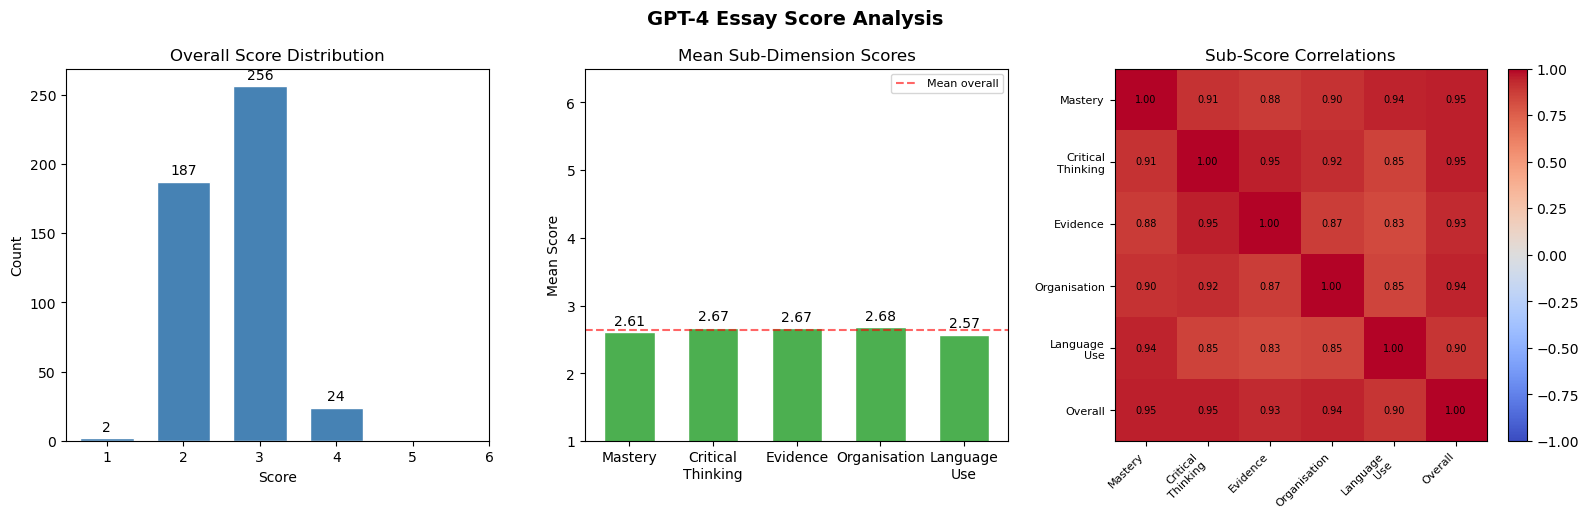

Plot saved → gpt4_score_analysis.png


In [17]:
if len(valid) == 0:
    print('No valid scores to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('GPT-4 Essay Score Analysis', fontsize=14, fontweight='bold')

    # ── Plot 1: Score distribution ────────────────────────────────────────
    ax = axes[0]
    dist = valid['score'].value_counts().sort_index()
    bars = ax.bar(dist.index, dist.values, color='steelblue', edgecolor='white', width=0.7)
    ax.bar_label(bars, padding=3)
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.set_title('Overall Score Distribution')
    ax.set_xticks(range(1, 7))

    # ── Plot 2: Sub-score means ───────────────────────────────────────────
    ax2 = axes[1]
    sub_cols = ['mastery_score', 'critical_thinking', 'evidence', 'organisation', 'language_use']
    sub_labels = ['Mastery', 'Critical\nThinking', 'Evidence', 'Organisation', 'Language\nUse']
    numeric_valid = valid.copy()
    for col in sub_cols:
        numeric_valid[col] = pd.to_numeric(numeric_valid[col], errors='coerce')
    means = numeric_valid[sub_cols].mean()
    bars2 = ax2.bar(sub_labels, means, color='#4CAF50', edgecolor='white', width=0.6)
    ax2.bar_label(bars2, fmt='%.2f', padding=3)
    ax2.set_ylim(1, 6.5)
    ax2.set_ylabel('Mean Score')
    ax2.set_title('Mean Sub-Dimension Scores')
    ax2.axhline(y=numeric_valid['score'].mean(), color='red', linestyle='--', alpha=0.6, label='Mean overall')
    ax2.legend(fontsize=8)

    # ── Plot 3: Sub-score correlation heatmap ─────────────────────────────
    ax3 = axes[2]
    heat_cols = sub_cols + ['score']
    heat_labels = sub_labels + ['Overall']
    corr = numeric_valid[heat_cols].corr()
    im = ax3.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax3.set_xticks(range(len(heat_labels))); ax3.set_xticklabels(heat_labels, rotation=45, ha='right', fontsize=8)
    ax3.set_yticks(range(len(heat_labels))); ax3.set_yticklabels(heat_labels, fontsize=8)
    for i in range(len(heat_labels)):
        for j in range(len(heat_labels)):
            ax3.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=ax3, fraction=0.046)
    ax3.set_title('Sub-Score Correlations')

    plt.tight_layout()
    plt.savefig('gpt4_score_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved → gpt4_score_analysis.png')

## 13. Sample GPT-4 Justifications

Review a few justifications to sanity-check GPT-4's reasoning.

In [18]:
sample_n = min(5, len(valid))
sample_rows = valid.sample(sample_n, random_state=42) if len(valid) >= sample_n else valid

for _, row in sample_rows.iterrows():
    print(f'essay_id : {row["essay_id"]}')
    print(f'Score    : {row["score"]}')
    print(f'Reason   : {row["justification"]}')
    print('-' * 70)

essay_id : 0105e2e
Score    : 3
Reason   : The essay demonstrates developing mastery with limited critical thinking and inconsistent evidence, and it is fairly organized with language use that has weaknesses.
----------------------------------------------------------------------
essay_id : 01846d8
Score    : 2
Reason   : The essay demonstrates little mastery with serious flaws in grammar and mechanics, weak critical thinking, insufficient evidence, poor organization, and limited language use.
----------------------------------------------------------------------
essay_id : 00b2fe2
Score    : 3
Reason   : The essay demonstrates developing mastery with limited critical thinking, inconsistent evidence, limited organization, and fair language use with weaknesses.
----------------------------------------------------------------------
essay_id : 07cde52
Score    : 2
Reason   : The essay demonstrates little mastery with serious flaws in organization, weak critical thinking, insufficient evide

## 14. (Optional) Evaluate vs Ground Truth

If you have a labelled dataset (e.g. your 80/20 validation split), run this cell to compute the Quadratic Weighted Kappa.

In [19]:
df_original = df_original[['essay_id','score']].iloc[:500]

df_original.head()

,essay_id,score
0,000d118,3
1,000fe60,3
2,001ab80,4
3,001bdc0,4
4,002ba53,3


In [20]:
# Change GROUND_TRUTH_CSV to your labelled file if available
# It must have columns: essay_id, score


from sklearn.metrics import cohen_kappa_score

gt = df_original[['essay_id', 'score']].rename(
    columns={'score': 'true_score'}
)
eval_df = submission.merge(gt, on='essay_id', how='inner')
eval_df = eval_df[
    eval_df['score'].between(1, 6) & eval_df['true_score'].between(1, 6)
]
qwk = cohen_kappa_score(eval_df['true_score'], eval_df['score'], weights='quadratic')
print(f'Evaluated on {len(eval_df):,} matched essays')
print(f'Quadratic Weighted Kappa (QWK) = {qwk:.4f}')

Evaluated on 469 matched essays
Quadratic Weighted Kappa (QWK) = 0.4287
